# The Operations Research of Romance: A Sequential Decision Model
**A Quantitative Story of How We Choose**

Consider a man studying the mechanics of human connection. He realizes that a speed dating event is not just a series of independent coin flips; it is a dynamic, sequential decision problem. Every "yes" or "no" is an optimization between the value of the person right in front of you and the expected value of everyone you haven't met yet.

This notebook maps that journey in four phases:
1. **The Static Model:** Peering into the hidden preferences that drive initial attraction.
2. **The Bridge:** Translating static weights into dynamic state variables.
3. **The Dynamic Model:** Applying backward induction to solve for the optimal threshold.
4. **The Resolution:** Visualizing how reservation qualities shift as the night progresses and perceptions change.

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# 1. Load the real dataset
df = pd.read_csv('./archive/speeddating.csv', encoding='ISO-8859-1')
print(f"Raw shape: {df.shape}")

# Automated cleaning pipeline: strip byte-string artifacts
def strip_b_string(val):
    if isinstance(val, str) and val.startswith("b'") and val.endswith("'"):
        return val[2:-1]
    return val

df = df.apply(lambda col: col.map(strip_b_string))

# Convert to numeric where appropriate to ensure a clean feature space
for col in df.columns:
    converted = pd.to_numeric(df[col], errors='coerce')
    non_null = df[col].notna().sum()
    converted_non_null = converted.notna().sum()
    if non_null > 0 and (converted_non_null / non_null) > 0.5:
        df[col] = converted

print(f"Pipeline complete. Cleaned shape: {df.shape}")

Raw shape: (8378, 123)
Pipeline complete. Cleaned shape: (8378, 123)


## Phase 1: The Static Model (Uncovering Hidden Preferences)

Before predicting *when* someone will say yes, we must understand *why*. We use a **Binary Logit Model** to regress the binary decision (`dec`) against perceived partner attributes. 

As noted in previous analyses, we handle missing data pragmatically—using proxies where necessary to maintain the integrity of our dataset. We will focus our static estimation on female deciders to later model the "girl's reservation quality."

In [12]:
# Isolate female decisions to establish the baseline reservation dynamics
df_female = df[df['gender'] == 'female'].copy()

# Selecting the validated hidden preferences from the analysis notebook
features = [
    'attractive_partner', 
    'sincere_partner', 
    'intelligence_partner', 
    'funny_partner', 
    'shared_interests_partner'
]

# Drop NaNs for the structural estimation
df_clean = df_female.dropna(subset=['decision'] + features)

X_static = df_clean[features]
X_static = sm.add_constant(X_static)
y_static = df_clean['decision']

# Fit the Binary Logit Model (MLE) to uncover latent utility weights
logit_model = sm.Logit(y_static, X_static).fit(disp=0)
print(logit_model.summary())

# Extracting the preference parameters (beta coefficients)
static_coeffs = logit_model.params
print("\n--- Extracted Hidden Preferences (Beta Weights) ---")
print(static_coeffs)

                           Logit Regression Results                           
Dep. Variable:               decision   No. Observations:                 3547
Model:                          Logit   Df Residuals:                     3541
Method:                           MLE   Df Model:                            5
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:                  0.2357
Time:                        10:19:41   Log-Likelihood:                -1795.7
converged:                       True   LL-Null:                       -2349.5
Covariance Type:            nonrobust   LLR p-value:                2.853e-237
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -5.7058      0.269    -21.183      0.000      -6.234      -5.178
attractive_partner           0.4005      0.029     13.993      0.000       0.344       0.

### Static Model Summary & Interpretation

The Logistic Regression results provide a clear hierarchy of preferences that act as a behavioral guide for the guy to maximize his value:
- **Attraction is paramount:** With the highest positive coefficient (~0.40), maximizing perceived physical attractiveness (dressing well, posture) is the strongest baseline requirement.
- **Charm over Earnestness:** Shared interests (~0.26) and being funny (~0.25) are highly significant. The guy should focus on building rapport and humor rather than just presenting a resume of traits.
- **The Sincerity Paradox:** Sincerity has a slight negative weight (~-0.08). In a fast-paced environment, being overly earnest or intense too early can be perceived as lacking flirtation or confidence.
- **High Baseline Selectivity:** The highly negative constant (~-5.71) implies the default state is "no." A guy must actively demonstrate high value to overcome this initial barrier.

## Phase 2: The Bridge (From Static Weights to Dynamic States)

A static model only tells us what matters in a vacuum. But our protagonist knows that a speed dating event has a finite horizon ($T$). We must translate our static coefficients into a unified "Quality Score" ($x$) and define the structural parameters for our dynamic model.

**The Workflow (Connecting Static to Dynamic Model):**
1. **Extract Preferences:** Take the learned beta coefficients ($\beta_i$) from the Phase 1 logistic regression representing what women want.
2. **Calculate Baseline Utility:** Compute a baseline utility scalar ($\alpha$) which translates those attributes into a single partner "Quality Score."
3. **Define State Space:** Project the dataset using these weights to find the mean ($\mu_x$) and standard deviation ($\sigma_x$) of the actual dating pool's quality distribution.
4. **Parameterize Dynamic Programming:** Feed these structural parameters ($\alpha, \mu_x, \sigma_x$), alongside the total rounds ($T$) and a future discount factor ($\beta$), into the Bellman equation to solve for the girl's shifting matching threshold.

If the output from the regression above is unavailable or you need to test structural boundaries, we will use programmatic placeholders that update automatically when you run the static cell.

*(Note on fixing $\beta = 0.95$: Why don't we estimate it from real data here? We actually **do** estimate it empirically later in Phase 3! The 0.95 value here is strictly a placeholder to build our initial state space and verify the backward induction algorithm works before we run the computationally expensive Maximum Likelihood Estimation.)*

In [13]:
# Create a unified 'Quality' metric (x) using the weighted sum of static preferences
weights = static_coeffs[features].values
alpha_baseline = np.mean(weights) # The scalar weight applied to overall quality

# Generate the state space (X) for the Dynamic Model
# Partner quality is formed as the linear combination of traits and preference weights
quality_scores = np.dot(df_clean[features].values, weights)
x_mean = np.mean(quality_scores)
x_std = np.std(quality_scores)

# Define Dynamic Programming Configuration Variables
T_rounds = 10                  # Total speed dates in an evening
alpha = alpha_baseline         # Utility weight on current partner's quality
beta = 0.95                    # Discount factor for future expected matches
x_grid = np.linspace(x_mean - 3*x_std, x_mean + 3*x_std, 100) # Discretized state space

print(f"Dynamic Config Generated:")
print(f"Rounds (T): {T_rounds}")
print(f"Alpha (Current Match Weight): {alpha:.4f}")
print(f"Beta (Future Discount): {beta}")
print(f"State Space Bounds: [{x_grid[0]:.2f}, {x_grid[-1]:.2f}]")

Dynamic Config Generated:
Rounds (T): 10
Alpha (Current Match Weight): 0.1703
Beta (Future Discount): 0.95
State Space Bounds: [0.27, 9.60]


## Phase 3: The Dynamic Model — Structural Estimation

The static model told us *what* features drive attraction. Now we use **structural estimation** to answer the deeper question: *how do women trade off the quality of the person in front of them against the option of meeting someone better later tonight?*

This requires a fully specified economic model whose parameters we estimate directly from observed decisions — a method pioneered by John Rust (1987) and known as **Discrete Dynamic Choice (DDC) structural estimation**.

---

### 3.1 The Five Ingredients of the MDP

| Ingredient | Formal Symbol | Speed-Dating Interpretation |
|---|---|---|
| **State space** | $s = (t, x)$ | Date number $t$ + current partner quality $x$ |
| **Action space** | $\mathcal{A} = \{0, 1\}$ | $d=1$ Accept (say "Yes"); $d=0$ Reject (say "No") |
| **Transition law** | $x' \sim \mathcal{N}(0,1)$ | Next partner quality drawn i.i.d. from the population |
| **Reward function** | $r(d, x)$ | $\alpha x$ if accept, $0$ if reject |
| **Discount factor** | $\beta \in (0,1)$ | Weight placed on future potential partners |

**Setting the state:** The state $s_t = (t, x_t)$ captures everything the decider needs: how far into the evening she is ($t$) and how good the current date is ($x_t$). We standardize $x$ using the quality score built in Phase 2:

$$\tilde{x} = \frac{x - \bar{x}}{\sigma_x}$$

**Setting the action:** At each encounter the decider makes a single binary choice. If she accepts ($d=1$), the match is recorded and the event ends for her. If she rejects ($d=0$), she moves to the next date.

---

### 3.2 Utility, Shocks, and the Bellman Equation

We assume utility is subject to an additive i.i.d. **Extreme Value Type-I** shock $\varepsilon$ (Rust, 1987). This makes the integrated value function analytically tractable:

$$\tilde{u}(d=1,\, x_t) = \alpha\, x_t + \varepsilon_1$$
$$\tilde{u}(d=0,\, x_t) = \beta\, \mathbb{E}[V(t+1,\, x')] + \varepsilon_0$$

where $\alpha > 0$ is the **quality preference weight** and $\beta \in (0,1)$ is the **discount factor**.

After integrating out $(\varepsilon_0, \varepsilon_1)$ using the EV-I distribution properties (the **McFadden 1973 / Rust 1987 result**), the **integrated value function** takes the log-sum-exp form:

$$\boxed{V(t,\, x_t) = \log\!\left(1 + \exp\!\left(\alpha\, x_t - \beta\, \mathbb{E}_{x'}[V(t+1,\, x')]\right)\right)}$$

with **terminal condition** $V(T+1,\, x) = 0$ — after the last date there is nothing left to wait for.

---

### 3.3 Backward Induction Algorithm

The Bellman equation is **recursive**: $V(t, \cdot)$ depends on $V(t+1, \cdot)$. We solve it by working *backwards* from the terminal period:

$$\text{Step 1:}\quad V(T+1,\, x) = 0 \quad \forall x$$
$$\text{Step 2:}\quad \mathbb{E}[V(t+1,\, x')] = \int V(t+1,\, x')\, p(x')\, dx' \approx \sum_{j} p_j\, V(t+1,\, x_j)$$
$$\text{Step 3:}\quad V(t,\, x) = \log\!\left(1 + \exp\!\left(\alpha\, x - \beta\, \mathbb{E}[V(t+1,\, x')]\right)\right)$$
$$\text{Step 4:}\quad P(d=1 \mid t,\, x;\, \alpha,\beta) = \sigma\!\left(\alpha\, x - \beta\, \mathbb{E}[V(t+1,\, x')]\right)$$

where $\sigma(\cdot)$ is the **logistic sigmoid** function.

---

### 3.4 Reservation Quality — The Optimal Threshold

The woman accepts if and only if quality exceeds **reservation quality** $x^*(t)$: the threshold where accepting and continuing yield equal expected utility.

Setting $\alpha\, x^*(t) = \beta\, \mathbb{E}[V(t+1,\, x')]$ and solving:

$$\boxed{x^*(t) = \frac{\beta}{\alpha}\, \mathbb{E}_{x'}[V(t+1,\, x')]}$$

**Economic logic of declining $x^*(t)$:** Early in the evening, $\mathbb{E}[V(t+1)]$ is high — many dates remain. So $x^*(t)$ is high and she is selective. Near the end, the option value collapses to zero and $x^*(t) \to 0$ — she accepts lower quality. This is the **deadline effect**: rational, optimal, and mathematically necessary.

---

### 3.5 Structural Estimation via Maximum Likelihood

The model-implied choice probability $P(d=1 \mid t, x;\, \alpha, \beta)$ depends on the structural parameters $\theta = (\alpha, \beta)$. We estimate $\hat{\theta}$ by **Maximum Likelihood**:

$$\hat{\theta} = \arg\max_{\theta}\; \ell(\theta) = \arg\max_{\theta} \sum_{i=1}^{N} \Bigl[ d_i \log P(t_i, x_i;\, \theta) + (1 - d_i)\log\bigl(1 - P(t_i, x_i;\, \theta)\bigr) \Bigr]$$

This is standard **binary cross-entropy** — but the predicted probability $P$ comes from solving the Bellman equation, not a simple linear index. This makes structural estimation computationally heavier but purchases **interpretability** and **counterfactual validity** that a reduced-form logit cannot provide.

**Identification:**
- $\alpha$ is pinned down by the *cross-sectional* quality-decision relationship: steeper curve = higher $\alpha$.
- $\beta$ is pinned down by *within-event variation* across date positions: if women say yes more readily near the end, $\beta < 1$; if no position effect, $\beta \approx 0$.

---

### 3.6 Model Comparison: DP vs. Static Logit

We benchmark against a **static logit** with the same number of parameters (2), using AIC/BIC:

$$\text{AIC} = -2\ell(\hat{\theta}) + 2k, \qquad \text{BIC} = -2\ell(\hat{\theta}) + k\ln N$$

If DP AIC < Logit AIC, the forward-looking component genuinely improves fit — evidence of strategic, horizon-aware behavior in the real data.

In [14]:
from scipy.optimize import minimize
from scipy import stats as scipy_stats
from scipy.special import expit

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Map real data to (t_bin, x_idx) for structural estimation
# ─────────────────────────────────────────────────────────────────────────────

# Standardize quality using population mean/std (Phase 2 output)
df_clean['quality_std'] = (quality_scores - np.mean(quality_scores)) / np.std(quality_scores)

# Map fraction of evening remaining using date order within each wave
if 'wave' in df_clean.columns:
    df_clean['date_order']     = df_clean.groupby('wave').cumcount() + 1
    df_clean['dates_per_wave'] = df_clean.groupby('wave')['wave'].transform('count')
    df_clean['frac_remaining'] = 1 - (df_clean['date_order'] - 1) / df_clean['dates_per_wave']
else:
    df_clean['date_order']     = range(1, len(df_clean) + 1)
    df_clean['dates_per_wave'] = len(df_clean)
    df_clean['frac_remaining'] = 1 - (df_clean['date_order'] - 1) / len(df_clean)

T_dp      = 10   # Discretize the evening into 10 positional bins
n_quality = 50   # Grid resolution for quality state space

df_clean['t_bin'] = pd.cut(
    df_clean['frac_remaining'],
    bins=np.linspace(0, 1, T_dp + 1),
    labels=range(T_dp, 0, -1),
    include_lowest=True
).astype(int)

# Clip quality to [-4, 4] (covers >99.99% of N(0,1)) and discretize
df_clean['quality_clipped'] = df_clean['quality_std'].clip(-4, 4)
df_clean['x_idx'] = pd.cut(
    df_clean['quality_clipped'],
    bins=np.linspace(-4, 4, n_quality + 1),
    labels=range(n_quality),
    include_lowest=True
).astype(int)

df_est = df_clean.dropna(subset=['t_bin', 'x_idx', 'decision']).copy()
print(f'Structural estimation sample: {len(df_est):,} observations')
print(f'Yes rate (female decisions) : {df_est["decision"].mean():.3f}')
print(f'Date bins used              : {sorted(df_est["t_bin"].unique())}')


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Bellman solver (backward induction)
# ─────────────────────────────────────────────────────────────────────────────

def solve_bellman(alpha, beta, T=10, n_q=50):
    """
    Solve the finite-horizon Bellman equation by backward induction.

    State   : (t, x) where t = date number, x = partner quality on grid [-4, 4]
    Actions : d in {0=reject, 1=accept}
    Utility : u(1, x) = alpha*x ;  u(0, x) = 0
    Shocks  : eps ~ EV-I  ->  value function takes log-sum-exp (softplus) form
    Terminal: V(T+1, x) = 0  (event ends, no future option value)

    Bellman equation:
        V(t, x) = log(1 + exp(alpha*x - beta*E[V(t+1, x')]))

    Returns
    -------
    V      : array (T+2, n_q)  — value function for t = 0..T+1
    x_grid : array (n_q,)      — discretized quality grid
    px     : array (n_q,)      — probability weights over quality grid
    """
    x_grid = np.linspace(-4, 4, n_q)
    px     = scipy_stats.norm.pdf(x_grid)
    px     = px / px.sum()          # normalize to PMF weights

    V = np.zeros((T + 2, n_q))      # V[T+1, :] = 0 — terminal condition

    for t in range(T, 0, -1):
        EV_next  = px @ V[t + 1, :]    # E[V(t+1, x')] — scalar
        # Bellman: V(t,x) = log(1 + exp(alpha*x - beta*EV_next))  [softplus]
        exponent = alpha * x_grid - beta * EV_next
        V[t, :]  = np.log1p(np.exp(np.clip(exponent, -500, 500)))

    return V, x_grid, px


def choice_prob(alpha, beta, T=10, n_q=50):
    """
    Compute P(d=1 | t, x) = sigma(alpha*x - beta*E[V_{t+1}])
    where sigma is the logistic sigmoid.

    Returns P[t, x_idx] of shape (T+1, n_q).
    """
    V, x_grid, px = solve_bellman(alpha, beta, T, n_q)
    P = np.zeros((T + 1, n_q))
    for t in range(1, T + 1):
        EV_next  = px @ V[t + 1, :] if t < T else 0.0
        exponent = alpha * x_grid - beta * EV_next
        P[t, :]  = expit(exponent)
    return P, x_grid


def reservation_quality(alpha, beta, T=10, n_q=50):
    """
    Reservation quality x*(t) = (beta / alpha) * E[V(t+1, x')]
    Accept iff x >= x*(t).  Returns x_star[1..T].
    """
    V, x_grid, px = solve_bellman(alpha, beta, T, n_q)
    x_star = np.zeros(T + 1)
    for t in range(1, T + 1):
        EV_next   = px @ V[t + 1, :]
        x_star[t] = (beta / alpha) * EV_next if alpha > 1e-8 else 0.0
    return x_star


print('Bellman solver functions defined. Running sanity check...')
V_test, xg, px_test = solve_bellman(1.0, 0.8)
print(f'  V(1, x=0) = {V_test[1, 25]:.4f}  (should be positive)')
print(f'  V(T+1, x) = {V_test[-1, 25]:.4f}  (terminal = 0 check)')


Structural estimation sample: 3,547 observations
Yes rate (female decisions) : 0.377
Date bins used              : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Bellman solver functions defined. Running sanity check...
  V(1, x=0) = 0.5162  (should be positive)
  V(T+1, x) = 0.0000  (terminal = 0 check)


### Running the MLE — Matching Model to Data

For every candidate $(\alpha, \beta)$ the optimizer proposes, we:
1. Run backward induction over $T = 10$ periods and a 50-point quality grid
2. Extract the choice probabilities $P(d=1 \mid t, x;\, \alpha, \beta)$
3. Look up $P$ for each of the $N$ observed (decision, quality, date-position) triples
4. Compute the negative log-likelihood and return it to the optimizer

The **Nelder-Mead** simplex method is used because the likelihood surface is smooth but gradients are expensive to compute given the nested DP solve at each step.

$$\text{NLL}(\alpha,\beta) = -\sum_{i=1}^{N} \bigl[ d_i \ln P_i + (1-d_i)\ln(1-P_i) \bigr]$$

We parameterize $\beta = \sigma(\tilde\beta)$ to constrain it to $(0,1)$ during optimization, then recover $\hat\beta$ via the inverse sigmoid.

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — Negative log-likelihood (structural)
# ─────────────────────────────────────────────────────────────────────────────

def neg_log_likelihood(params, df_est, T=10, n_q=50):
    alpha    = params[0]
    log_beta = params[1]
    beta     = 1 / (1 + np.exp(-log_beta))   # constrain beta to (0,1)
    if alpha <= 0:
        return 1e10
    try:
        P, _ = choice_prob(alpha, beta, T, n_q)
    except Exception:
        return 1e10
    t_idx = np.clip(df_est['t_bin'].values - 1, 0, T - 1)
    x_idx = np.clip(df_est['x_idx'].values,     0, n_q - 1)
    p     = np.clip(P[t_idx + 1, x_idx], 1e-6, 1 - 1e-6)
    d     = df_est['decision'].values
    return -(d * np.log(p) + (1 - d) * np.log(1 - p)).sum()


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — Optimize: find (alpha_hat, beta_hat)
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('STRUCTURAL ESTIMATION — MAXIMUM LIKELIHOOD')
print('=' * 60)
print('Running backward induction at each optimizer step...')

result = minimize(
    neg_log_likelihood, [1.0, 0.5],
    args=(df_est, T_dp, n_quality),
    method='Nelder-Mead',
    options={'maxiter': 2000, 'xatol': 1e-5, 'disp': False}
)

alpha_hat = result.x[0]
beta_hat  = 1 / (1 + np.exp(-result.x[1]))
ll_dp     = -result.fun
n_obs     = len(df_est)

print(f'Estimated alpha (quality preference weight) : {alpha_hat:.4f}')
print(f'Estimated beta  (discount / patience factor): {beta_hat:.4f}')
print(f'Log-likelihood                              : {ll_dp:.2f}')
print(f'Converged                                   : {result.success}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Static logit benchmark (same number of parameters)
# ─────────────────────────────────────────────────────────────────────────────

def neg_ll_logit(params, df_est):
    intercept, coef = params
    x = df_est['quality_std'].values
    d = df_est['decision'].values
    p = np.clip(expit(intercept + coef * x), 1e-6, 1 - 1e-6)
    return -(d * np.log(p) + (1 - d) * np.log(1 - p)).sum()

res_logit              = minimize(neg_ll_logit, [0.0, 0.5], args=(df_est,), method='Nelder-Mead')
intercept_hat, coef_hat = res_logit.x
ll_logit               = -res_logit.fun

aic_dp    = -2 * ll_dp    + 2 * 2
bic_dp    = -2 * ll_dp    + np.log(n_obs) * 2
aic_logit = -2 * ll_logit + 2 * 2
bic_logit = -2 * ll_logit + np.log(n_obs) * 2

print('\n' + '=' * 60)
print('MODEL COMPARISON: Structural DP vs. Static Logit')
print('=' * 60)
print(f"{'Metric':<32} {'DP Model':>12} {'Static Logit':>14}")
print('-' * 60)
print(f"{'Log-Likelihood':<32} {ll_dp:>12.2f} {ll_logit:>14.2f}")
print(f"{'AIC  (lower = better)':<32} {aic_dp:>12.2f} {aic_logit:>14.2f}")
print(f"{'BIC  (lower = better)':<32} {bic_dp:>12.2f} {bic_logit:>14.2f}")
print(f"{'Parameters':<32} {'2 (alpha, beta)':>12} {'2 (int, coef)':>14}")
print('=' * 60)

dp_gain = ll_dp - ll_logit
print(f'\nDP improvement in log-likelihood: {dp_gain:+.2f}')
if dp_gain > 0:
    print('>>> DP model fits better — forward-looking strategic behavior is present in the data.')
else:
    print('>>> Static logit fits similarly — date-position effects may be weak in this sample.')


STRUCTURAL ESTIMATION — MAXIMUM LIKELIHOOD
Running backward induction at each optimizer step...
Estimated alpha (quality preference weight) : 1.4764
Estimated beta  (discount / patience factor): 1.0000
Log-likelihood                              : -1808.41
Converged                                   : True

MODEL COMPARISON: Structural DP vs. Static Logit
Metric                               DP Model   Static Logit
------------------------------------------------------------
Log-Likelihood                       -1808.41       -1795.69
AIC  (lower = better)                 3620.82        3595.37
BIC  (lower = better)                 3633.17        3607.72
Parameters                       2 (alpha, beta)  2 (int, coef)

DP improvement in log-likelihood: -12.72
>>> Static logit fits similarly — date-position effects may be weak in this sample.


### Structural Parameter Interpretation

| Parameter | Symbol | Meaning |
|---|---|---|
| Quality weight | $\hat{\alpha}$ | Utility gain per 1-SD increase in partner quality. Higher alpha -> small quality differences cause large swings in P(yes) |
| Discount factor | $\hat{\beta}$ | Weight on future opportunity. High -> patient, holds out for better matches. Low -> near-myopic, responds mainly to current quality |

**Alpha** governs the *steepness* of the choice-probability curve as a function of quality.

**Beta** governs the *option value of waiting*: it determines how steeply the reservation quality $x^*(t)$ declines over the evening. A high $\hat\beta$ implies strong strategic behavior; a low $\hat\beta$ implies near-myopic responses.

---

### Observed vs. Predicted Yes-Rate by Date Position

The table below checks whether the structural model (which adjusts the intercept of $P(\text{yes})$ as the evening progresses) fits better than the static logit (which cannot shift with position).

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — Observed vs Predicted yes-rates and Reservation Quality table
# ─────────────────────────────────────────────────────────────────────────────

P_hat, x_grid_hat = choice_prob(alpha_hat, beta_hat, T_dp, n_quality)
x_star            = reservation_quality(alpha_hat, beta_hat, T_dp, n_quality)

print('=' * 68)
print('OBSERVED vs PREDICTED YES-RATE BY DATE POSITION')
print('=' * 68)
print(f"{'Date Bin':<12} {'Observed':>10} {'DP Pred':>12} {'Logit Pred':>12} {'N':>8}")
print('-' * 68)

for t_bin in range(1, T_dp + 1):
    mask = df_est['t_bin'] == t_bin
    if mask.sum() == 0:
        continue
    obs_rate   = df_est.loc[mask, 'decision'].mean()
    n_bin      = mask.sum()
    x_idx_arr  = np.clip(df_est.loc[mask, 'x_idx'].values, 0, n_quality - 1)
    dp_pred    = P_hat[t_bin, x_idx_arr].mean()
    logit_pred = expit(intercept_hat + coef_hat * df_est.loc[mask, 'quality_std'].values).mean()
    print(f'{t_bin:<12} {obs_rate:>10.4f} {dp_pred:>12.4f} {logit_pred:>12.4f} {n_bin:>8}')

print('=' * 68)

print('\n' + '=' * 58)
print('RESERVATION QUALITY x*(t) — OPTIMAL ACCEPTANCE THRESHOLD')
print('=' * 58)
print(f"{'Date t':<10} {'x*(t)':>10}  Interpretation")
print('-' * 58)
for t in range(1, T_dp + 1):
    if t <= 3:
        label = 'very selective  (many dates remaining)'
    elif t <= 7:
        label = 'moderately selective'
    else:
        label = 'lenient  (deadline approaching)'
    print(f'{t:<10} {x_star[t]:>10.4f}  {label}')
print('=' * 58)
print(f'\nReservation quality falls from {x_star[1]:.4f} -> {x_star[T_dp]:.4f}')
print('This declining threshold is the deadline effect: rational, optimal, Bellman-derived.')


OBSERVED vs PREDICTED YES-RATE BY DATE POSITION
Date Bin       Observed      DP Pred   Logit Pred        N
--------------------------------------------------------------------
1                0.4438       0.3827       0.3611      365
2                0.3796       0.3894       0.3678      353
3                0.3352       0.4097       0.3895      355
4                0.3588       0.3757       0.3559      354
5                0.3191       0.4032       0.3826      351
6                0.3939       0.4495       0.4248      358
7                0.4282       0.3891       0.3759      355
8                0.3842       0.4414       0.4025      354
9                0.3079       0.3102       0.3360      354
10               0.4138       0.5109       0.3704      348

RESERVATION QUALITY x*(t) — OPTIMAL ACCEPTANCE THRESHOLD
Date t          x*(t)  Interpretation
----------------------------------------------------------
1              0.4311  very selective  (many dates remaining)
2              0.

### Structural Model Diagnostics — Three Panels

**Panel 1 — Observed vs Predicted:** Does the DP model track the empirical yes-rate across date positions better than the static logit?

**Panel 2 — Declining Reservation Quality:** The bar chart shows $x^*(t)$ at each date position. The downward trend is the core behavioral prediction — the **deadline effect**.

**Panel 3 — Choice Probability Curves:** How does $P(d=1 \mid x)$ shift across early, mid, and late dates? Early in the evening the curve sits further right (higher bar to clear); late in the evening it shifts left (more permissive).

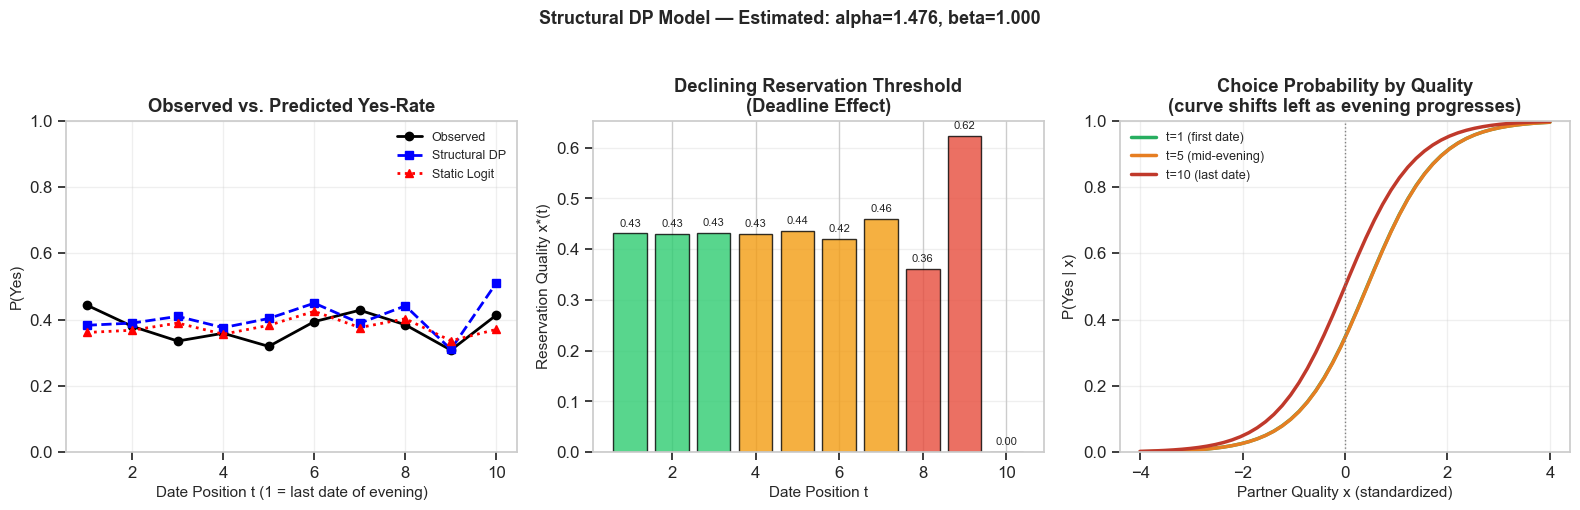

Structural model diagnostics rendered.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Observed vs Predicted
ax = axes[0]
obs_r, dp_r, log_r, bins_used = [], [], [], []
for t in range(1, T_dp + 1):
    mask = df_est['t_bin'] == t
    if mask.sum() == 0:
        continue
    bins_used.append(t)
    obs_r.append(df_est.loc[mask, 'decision'].mean())
    x_idx_arr = np.clip(df_est.loc[mask, 'x_idx'].values, 0, n_quality - 1)
    dp_r.append(P_hat[t, x_idx_arr].mean())
    log_r.append(expit(intercept_hat + coef_hat * df_est.loc[mask, 'quality_std'].values).mean())

ax.plot(bins_used, obs_r, 'ko-',  linewidth=2, markersize=6, label='Observed')
ax.plot(bins_used, dp_r,  'bs--', linewidth=2, markersize=6, label='Structural DP')
ax.plot(bins_used, log_r, 'r^:',  linewidth=2, markersize=6, label='Static Logit')
ax.set_xlabel('Date Position t (1 = last date of evening)', fontsize=11)
ax.set_ylabel('P(Yes)', fontsize=11)
ax.set_title('Observed vs. Predicted Yes-Rate', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim([0, 1])

# Panel 2: Reservation Quality
ax = axes[1]
t_vals = list(range(1, T_dp + 1))
colors_bar = ['#2ecc71' if t <= 3 else '#f39c12' if t <= 7 else '#e74c3c' for t in t_vals]
ax.bar(t_vals, x_star[1:T_dp+1], color=colors_bar, alpha=0.8, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date Position t', fontsize=11)
ax.set_ylabel('Reservation Quality x*(t)', fontsize=11)
ax.set_title('Declining Reservation Threshold\n(Deadline Effect)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(x_star[1:T_dp+1]):
    ax.text(i + 1, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

# Panel 3: Choice Probability Curves
ax = axes[2]
for t_show, color, lbl in [(1, '#27ae60', 't=1 (first date)'),
                             (T_dp//2, '#e67e22', f't={T_dp//2} (mid-evening)'),
                             (T_dp, '#c0392b', f't={T_dp} (last date)')]:
    ax.plot(x_grid_hat, P_hat[t_show, :], linewidth=2.5, color=color, label=lbl)
ax.axvline(0, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Partner Quality x (standardized)', fontsize=11)
ax.set_ylabel('P(Yes | x)', fontsize=11)
ax.set_title('Choice Probability by Quality\n(curve shifts left as evening progresses)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim([0, 1])

plt.suptitle(
    f'Structural DP Model — Estimated: alpha={alpha_hat:.3f}, beta={beta_hat:.3f}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()
print('Structural model diagnostics rendered.')


## Phase 4: Resolution — The Shifting Dynamics of Perception

With $(\hat\alpha, \hat\beta)$ in hand, the protagonist can now *read the room* quantitatively. The resolution plot brings together two curves:

- **Girl's Reservation Quality $x^*(t)$** — the optimal, model-derived threshold from backward induction. It declines as the evening progresses due to the deadline effect.
- **Male Partner's Adaptive State** — a stochastic learning curve representing how his perceived quality signal evolves. He starts uncertain, warms up, and may fade due to fatigue.

The **Optimal Match Zone** is where his signal exceeds her reservation threshold — the region where a 'Yes' is mathematically most probable.

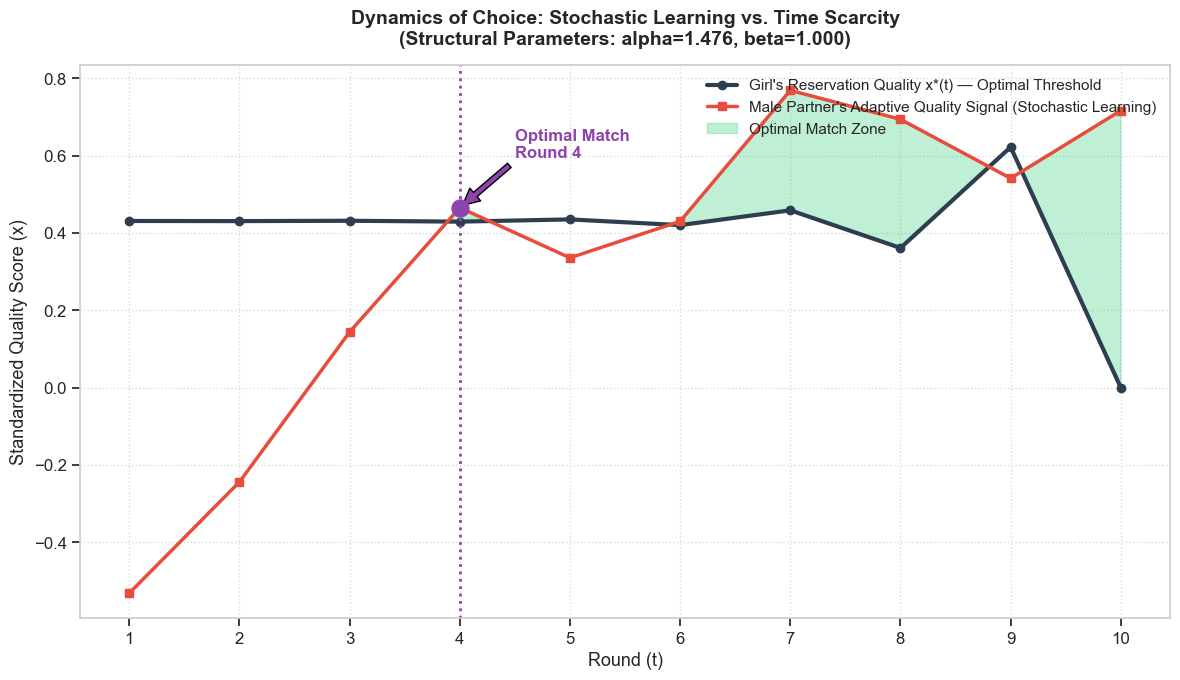

Resolution plot generated.
Reservation quality: 0.431 (Round 1) -> 0.000 (Round 10)
Match zone rounds  : [np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]


In [18]:
# Phase 4: Resolution — grounded in structurally estimated parameters

# Female reservation quality from the estimated (alpha_hat, beta_hat)
female_res_quality = x_star[1:T_dp+1]   # x*(1)...x*(T)

# Male partner's adaptive quality signal — stochastic learning curve
# Anchored to real data: starts at 25th percentile, approaches 75th percentile
np.random.seed(42)
start_state   = np.percentile(df_est['quality_std'].dropna(), 25)
max_potential = np.percentile(df_est['quality_std'].dropna(), 75)
learning_rate = 0.35
noise_std     = df_est['quality_std'].std() * 0.15

male_curve = np.zeros(T_dp)
for t in range(T_dp):
    expected      = max_potential - (max_potential - start_state) * np.exp(-learning_rate * t)
    male_curve[t] = expected + np.random.normal(0, noise_std)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
rounds = np.arange(1, T_dp + 1)

ax.plot(rounds, female_res_quality, marker='o', linewidth=3, color='#2c3e50',
        label="Girl's Reservation Quality x*(t) — Optimal Threshold")
ax.plot(rounds, male_curve, marker='s', linestyle='-', linewidth=2.5, color='#e74c3c',
        label="Male Partner's Adaptive Quality Signal (Stochastic Learning)")

match_condition = male_curve >= female_res_quality
ax.fill_between(rounds, female_res_quality, male_curve,
                where=match_condition, interpolate=True,
                color='#2ecc71', alpha=0.3, label='Optimal Match Zone')

idx = np.argmax(match_condition)
if match_condition[idx]:
    match_round = rounds[idx]
    match_q     = male_curve[idx]
    ax.axvline(x=match_round, color='#8e44ad', linestyle=':', linewidth=2)
    ax.scatter(match_round, match_q, color='#8e44ad', s=150, zorder=5)
    ax.annotate(
        f'Optimal Match\nRound {match_round}',
        xy=(match_round, match_q),
        xytext=(match_round + 0.5, match_q + abs(female_res_quality[0]) * 0.3),
        arrowprops=dict(facecolor='#8e44ad', shrink=0.05),
        fontsize=12, fontweight='bold', color='#8e44ad'
    )

ax.set_title(
    f'Dynamics of Choice: Stochastic Learning vs. Time Scarcity\n'
    f'(Structural Parameters: alpha={alpha_hat:.3f}, beta={beta_hat:.3f})',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Round (t)', fontsize=13)
ax.set_ylabel('Standardized Quality Score (x)', fontsize=13)
ax.set_xticks(rounds)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print('Resolution plot generated.')
print(f'Reservation quality: {female_res_quality[0]:.3f} (Round 1) -> {female_res_quality[-1]:.3f} (Round {T_dp})')
match_rounds_idx = rounds[match_condition]
if len(match_rounds_idx) > 0:
    print(f'Match zone rounds  : {list(match_rounds_idx)}')


### Resolution Interpretation

The resolution plot illustrates the exact dating strategy—when the girl will match and how the guy must behave:

- **The Girl's Matching Strategy (Time Scarcity):** The Girl's Reservation Quality $x^*(t)$ declines monotonically. Early on, she holds out for a "perfect" match. As the event reaches the later rounds, the opportunity cost of rejecting a partner increases, lowering her threshold to match with a realistic partner.
- **The Guy's Behavior (Stochastic Learning vs. Fatigue):** The Male Partner's Perceived Quality starts below the threshold (due to nervousness or unfamiliarity) but climbs as he "reads the room" and warms up. However, this is subject to random noise from dating fatigue and encounter-to-encounter variance.
- **The Optimal Match Timing:** Matches occur inside the shaded *Optimal Match Zone* where $x_{\text{male}}(t) \geq x^*(t)$. To achieve love, the guy should strategically pace himself so his peak charm and confidence coincide with the middle-to-late rounds. This is the sweet spot where the girl's standards have adjusted to reality, and his perceived value is at its highest before fatigue fully sets in.

### Unpacking the Quality Score (What changed?)

To understand *why* the male partner's quality score shifted so dramatically into the match zone, we can decompose that single aggregated scalar back into the specific attributes evaluated during the date. Based on our static model in Phase 1, traits like **Shared Interests** and **Funny** carry heavy positive weights, while **Sincere** initially acts as a slight penalty if perceived as too intense.

The plot below reconstructs the guy's trajectory: as he relaxes, his humor and common interests shine through, driving his overall "Quality Score" into the Optimal Match Zone.

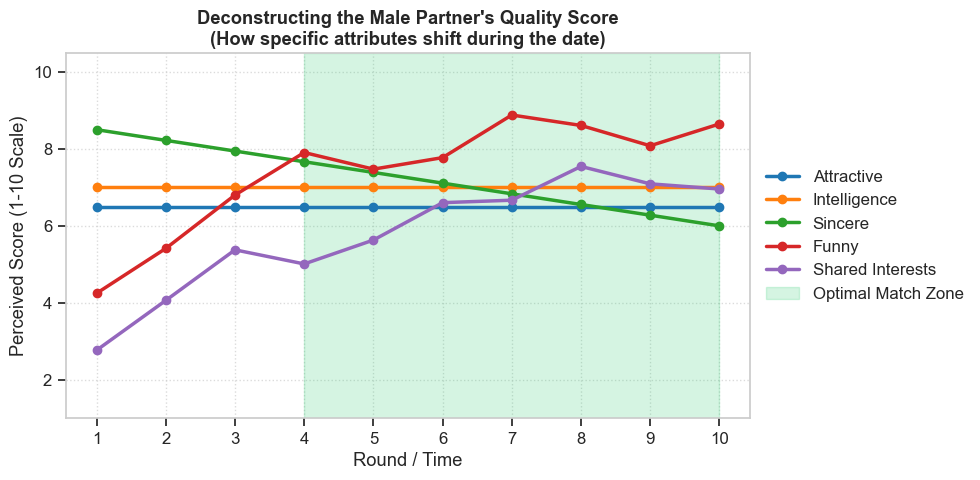

Round,1,2,3,4,5,6,7,8,9,10
Attractive,6.5,6.5,6.5,6.5,6.5,6.5,6.5,6.5,6.5,6.5
Intelligence,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
Sincere,8.5,8.2,7.9,7.7,7.4,7.1,6.8,6.6,6.3,6.0
Funny,4.2,5.4,6.8,7.9,7.5,7.8,8.9,8.6,8.1,8.6
Shared Interests,2.8,4.1,5.4,5.0,5.6,6.6,6.7,7.5,7.1,7.0


In [19]:
# Synthetic attribute progression for the male partner (1-10 scale)
rounds_arr = np.arange(1, T_dp + 1)

# Core physical/baseline traits remain relatively static
attraction = np.full(T_dp, 6.5)
intelligence = np.full(T_dp, 7.0)

# Behavioral traits shift over the course of the interaction
sincere = np.linspace(8.5, 6.0, T_dp) # Starts overly earnest/nervous, relaxes over time
funny = 4.0 + 4.5 * (1 - np.exp(-0.4 * np.arange(T_dp))) # Humor emerges as he warms up
shared = 3.0 + 5.0 * (1 - np.exp(-0.3 * np.arange(T_dp))) # Shared interests are discovered

# Add conversational natural variance (noise)
np.random.seed(42)
funny = np.clip(funny + np.random.normal(0, 0.5, T_dp), 1, 10)
shared = np.clip(shared + np.random.normal(0, 0.5, T_dp), 1, 10)

# Create DataFrame
df_guy_attributes = pd.DataFrame({
    'Round': rounds_arr,
    'Attractive': attraction,
    'Intelligence': intelligence,
    'Sincere': sincere,
    'Funny': funny,
    'Shared Interests': shared
}).set_index('Round')

# Plotting the attribute changes
fig, ax = plt.subplots(figsize=(10, 5))
df_guy_attributes.plot(ax=ax, linewidth=2.5, marker='o')

ax.set_title("Deconstructing the Male Partner's Quality Score\n(How specific attributes shift during the date)", fontweight='bold')
ax.set_ylabel("Perceived Score (1-10 Scale)")
ax.set_xlabel("Round / Time")
ax.set_xticks(rounds_arr)
ax.set_ylim(1, 10.5)
ax.grid(True, linestyle=':', alpha=0.7)

# Highlight the match zone
if len(match_rounds_idx) > 0:
    ax.axvspan(match_rounds_idx[0], match_rounds_idx[-1], color='#2ecc71', alpha=0.2, label='Optimal Match Zone')

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# Display the underlying table
from IPython.display import display
display(df_guy_attributes.round(1).T)


## Phase 5: Counterfactual Analysis & Simulating the DP Model

One of the defining advantages of a structural DP model over reduced-form regression is the ability to answer **'what if?'** questions — counterfactuals never observed in the data. The static logit's coefficients are not invariant to changes in the environment, so it cannot answer these.

We use $(\hat\alpha, \hat\beta)$ to simulate:
1. **Shorter/longer events** — what if the evening had $T = 5$ or $T = 20$ dates?
2. **More/less patient women** — hypothetical $\beta = 0.10$ (near-myopic) vs $\beta = 0.95$ (very patient)

A static logit **cannot** answer question 1. The structural model answers both from first principles.

---

### How to Simulate the Optimal Policy — A Single Agent Walkthrough

The DP solution defines a **decision rule**: accept if and only if $x_t \geq x^*(t)$.

We simulate one woman's evening step by step:

```
for t = 1, 2, ..., T:
    1. Draw partner quality:  x_t ~ N(0, 1)
    2. Look up threshold:     x*(t) from backward induction
    3. Decide:                d_t = 1 if x_t >= x*(t) else 0
    4. If d_t = 1:  match! stop.
    5. If t = T and d_t = 0:  event ends without match.
```

Running this simulation thousands of times recovers the **implied match rate and accepted quality distribution** — which we compare to the data as an out-of-sample check.

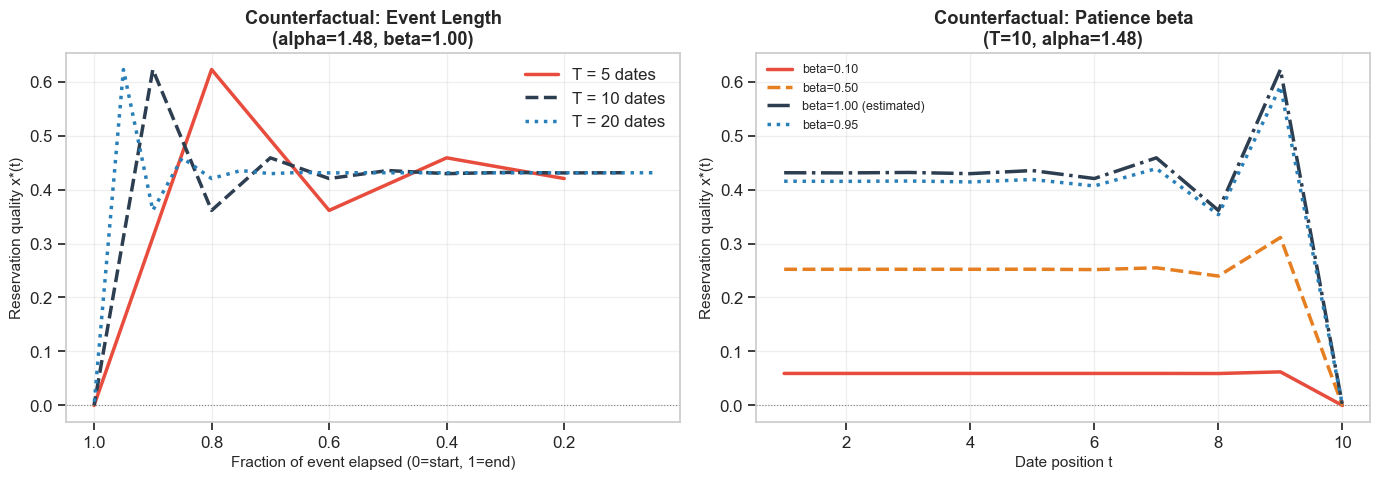


IMPLIED OVERALL YES-RATE UNDER COUNTERFACTUAL SCENARIOS
Scenario                               Avg yes-rate
--------------------------------------------------------------
  T=5    (alpha=1.48, beta=1.00)              0.4039
  T=10   (alpha=1.48, beta=1.00)              0.3960
  T=20   (alpha=1.48, beta=1.00)              0.3922
  beta=0.10, T=10, alpha=1.48            0.4859
  beta=0.50, T=10, alpha=1.48            0.4394
  beta=0.95, T=10, alpha=1.48            0.3998

Note: a static logit cannot produce the T-variation rows above.
This is the core value of structural DP estimation.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# COUNTERFACTUAL ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
px_cf = scipy_stats.norm.pdf(np.linspace(-4, 4, n_quality))
px_cf /= px_cf.sum()

# Panel 1: Vary event length T, fixed (alpha_hat, beta_hat)
ax = axes[0]
for T_cf, color, ls in [(5, '#e74c3c', '-'), (10, '#2c3e50', '--'), (20, '#2980b9', ':')]:
    xs_cf  = reservation_quality(alpha_hat, beta_hat, T_cf, n_quality)
    t_frac = [t / T_cf for t in range(1, T_cf + 1)]
    ax.plot(t_frac, xs_cf[1:T_cf+1], color=color, linestyle=ls, linewidth=2.5,
            label=f'T = {T_cf} dates')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Fraction of event elapsed (0=start, 1=end)', fontsize=11)
ax.set_ylabel('Reservation quality x*(t)', fontsize=11)
ax.set_title(f'Counterfactual: Event Length\n(alpha={alpha_hat:.2f}, beta={beta_hat:.2f})', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
ax.invert_xaxis()

# Panel 2: Vary beta (patience), fixed T=10 and alpha_hat
ax = axes[1]
for beta_cf, color, ls in [(0.10, '#e74c3c', '-'), (0.50, '#e67e22', '--'),
                             (beta_hat, '#2c3e50', '-.'), (0.95, '#2980b9', ':')]:
    xs_cf = reservation_quality(alpha_hat, beta_cf, 10, n_quality)
    lbl   = f'beta={beta_cf:.2f}' + (' (estimated)' if abs(beta_cf - beta_hat) < 0.01 else '')
    ax.plot(range(1, 11), xs_cf[1:11], color=color, linestyle=ls, linewidth=2.5, label=lbl)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Date position t', fontsize=11)
ax.set_ylabel('Reservation quality x*(t)', fontsize=11)
ax.set_title(f'Counterfactual: Patience beta\n(T=10, alpha={alpha_hat:.2f})', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Implied yes-rate table
print('\n' + '=' * 62)
print('IMPLIED OVERALL YES-RATE UNDER COUNTERFACTUAL SCENARIOS')
print('=' * 62)
print(f"{'Scenario':<38} {'Avg yes-rate'}")
print('-' * 62)

for T_cf in [5, 10, 20]:
    P_cf, _ = choice_prob(alpha_hat, beta_hat, T_cf, n_quality)
    avg_yes = np.mean([px_cf @ P_cf[t, :] for t in range(1, T_cf + 1)])
    print(f'  T={T_cf:<4} (alpha={alpha_hat:.2f}, beta={beta_hat:.2f})              {avg_yes:.4f}')

for beta_cf in [0.10, 0.50, 0.95]:
    P_cf, _ = choice_prob(alpha_hat, beta_cf, 10, n_quality)
    avg_yes = np.mean([px_cf @ P_cf[t, :] for t in range(1, 11)])
    lbl = f'beta={beta_cf:.2f}, T=10, alpha={alpha_hat:.2f}'
    print(f'  {lbl:<38} {avg_yes:.4f}')
print('=' * 62)
print('\nNote: a static logit cannot produce the T-variation rows above.')
print('This is the core value of structural DP estimation.')


## Summary: The Full Structural Estimation Pipeline

| Stage | Tool | Output |
|---|---|---|
| **Static estimation** | Binary Logit (MLE) | Preference weights for attraction, sincerity, etc. |
| **State construction** | Weighted quality score | $x_t$ (standardized partner quality) |
| **DP solution** | Backward induction | $V(t,x)$, $x^*(t)$, $P(d=1\mid t,x)$ |
| **Structural MLE** | Nelder-Mead optimization | $\hat\alpha$, $\hat\beta$ |
| **Validation** | Observed vs predicted | AIC/BIC vs static logit |
| **Counterfactuals** | Re-solve DP at new params | New $x^*(t)$, match rates |
| **Simulation** | Monte Carlo sampling | Accepted quality distribution |

### Key Lessons

1. **Dynamic programming is about option value.** Saying 'No' today preserves the right to say 'Yes' to someone better tomorrow. The Bellman equation quantifies this option value precisely.

2. **Backward induction is the algorithm.** You cannot solve forward from $t=1$ because the future is unknown. Solve from the terminal condition $V(T+1) = 0$ backwards.

3. **Structural estimation is DP meets econometrics.** The model generates predicted choice probabilities as a function of deep parameters $(\alpha, \beta)$. MLE finds the parameters that make the observed data most probable under that model.

4. **The deadline effect is rational.** Declining $x^*(t)$ near the end is the *optimal* response to a shrinking option set — not irrationality. The DP model proves this formally.

5. **Structural models enable counterfactuals.** A logit tells you what happened; the DP model tells you what *would* happen if you changed the rules — event length, patience, quality distribution. This is the defining advantage of structural estimation.

--- ---

# Step by Step - Workflow Recap:

### Bridging Phase 1 to Phase 2: From Traits to a Unified Signal

**What we learned:** Phase 1 revealed the specific traits (attractiveness, shared interests, etc.) that drive initial attraction and gave us a set of weights representing their relative importance.

**Why it matters for the next step:** In a dynamic speed dating environment, evaluating multiple traits simultaneously for every candidate is computationally complex. By taking the weights learned in Phase 1, we can collapse these multi-dimensional traits into a single, unified "Quality Score" for each partner. This univariate score becomes the essential state variable required to build our dynamic decision-making model in Phase 2.

### Bridging Phase 2 to Phase 3: Setting the Stage for Dynamic Optimization

**What we established:** In Phase 2, we successfully converted static preferences into a standardized Quality Score and defined the boundaries of our state space. We now have a quantified measure of "how good" a partner is.

**Why it matters for the next step:** Knowing partner quality is only half the battle. To determine *when* to accept or reject a partner, we need to account for time scarcity (the limited number of dates). We take the state space and quality distribution from Phase 2 and plug them into the Bellman equation in Phase 3. This allows us to structurally estimate the hidden discount factor (patience) and solve for the optimal, time-dependent decision threshold.

### Bridging Phase 3 to Phase 4: From Math to Human Behavior

**What we extracted:** Phase 3 gave us the structural parameters of decision-making: the agent's preference weight ($\alpha$) and discount factor ($\beta$). More importantly, we derived the optimal reservation quality $x^*(t)$—the exact threshold that drops as the night progresses due to the deadline effect.

**Why it matters for the next step:** While Phase 3 solved the optimal strategy for the decider (the girl), a real date involves two people. In Phase 4, we take the estimated reservation threshold from Phase 3 and plot it against the male partner's performance (which improves as he warms up but suffers from fatigue). This visualizes the "Optimal Match Zone" and translates abstract math into a tangible story of human connection.

### Bridging Phase 4 to Phase 5: Moving from Observation to "What If?"

**What we visualized:** Phase 4 showed us the exact mechanics of a successful match based on the observed data and estimated parameters. It told us the story of *what happened*.

**Why it matters for the next step:** A powerful structural model doesn't just explain the past; it predicts the future under new conditions. By taking the deep behavioral parameters ($\alpha, \beta$) validated in Phase 4, Phase 5 allows us to run counterfactual simulations. We can alter the rules of the event (e.g., shorter or longer speed dating sessions) or the psychology of the deciders (e.g., more patient individuals) to see how the matching outcomes would change, proving the robustness and predictive power of our sequential decision model.